In [1]:
#Install and import
!pip install yfinance hmmlearn pandas numpy matplotlib seaborn

import yfinance as yf
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

## Download the necessary data.

In [3]:
vix = yf.download("^VIX", start="2000-01-01", auto_adjust="True")
spy = yf.download("SPY", start="2000-01-01", auto_adjust="True")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Grab the necessary columns, clean, and calculate our log returns for SPY

In [5]:
spy_close = spy["Close"].dropna()
vix_close = vix["Close"].dropna()

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()

## Data Overview

### SPY Log Returns (2000–Present)
- **Mean**: 0.0003 — small positive drift, reflects long-term upward trend
- **Std**: 0.012 — ~1.2% average daily volatility
- **Min**: -0.116 — worst single day crash (likely March 2020 or Oct 2008)
- **Max**: 0.136 — largest single day gain (likely post-crash recovery)

### VIX (2000–Present)
- **Mean**: 19.8 — historically anything below 20 is considered calm
- **Min**: 9.14 — extremely low fear, deep bull market conditions
- **Max**: 82.69 — COVID March 2020, peak panic
- **75th percentile**: 23.2 — 75% of days VIX was below 23, so above this is elevated fear

In [7]:
print(log_returns.describe())
print()
print(vix_close.describe())

Ticker          SPY
count   6633.000000
mean       0.000314
std        0.012177
min       -0.115887
25%       -0.004594
50%        0.000690
75%        0.005977
max        0.135578

Ticker         ^VIX
count   6634.000000
mean      19.839628
std        8.319952
min        9.140000
25%       14.020000
50%       17.830000
75%       23.219999
max       82.690002


## Plotting SPY & VIX Closing Prices

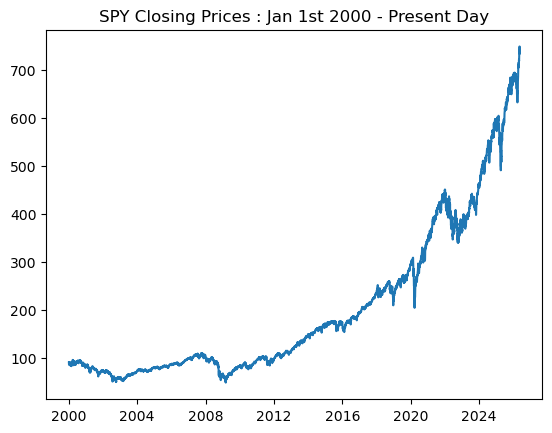

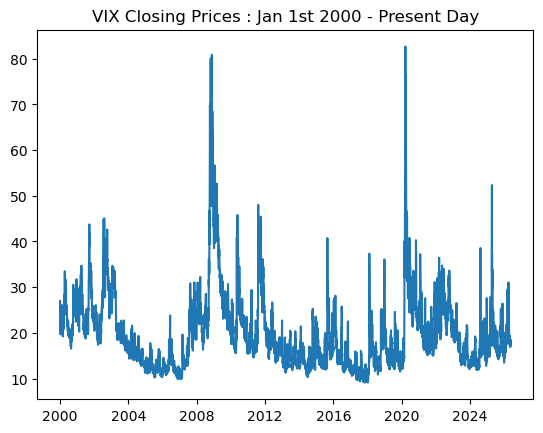

In [9]:
plt.plot(spy_close)
plt.title('SPY Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

plt.plot(vix_close)
plt.title('VIX Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

## Create / Clean the Data Frame

In [11]:
df = pd.concat([log_returns, vix_close], axis=1)
df_cleaned = df.dropna()
df_cleaned.shape

(6633, 2)

## Normalizing Values

Because the values of VIX are much higher than the ones in SPY, here we standardize the values to be centered around a mean of 0 and a standard deviation of 1

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
print(df_scaled)

[[-3.30209666  0.86192569]
 [ 0.12100813  0.78980835]
 [-1.35648215  0.70807537]
 ...
 [-1.01977152 -0.16935167]
 [-0.08358965 -0.242671  ]
 [-0.57469009 -0.2138241 ]]


In [14]:
from hmmlearn import hmm
import collections

model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)

model.fit(df_scaled)
states = model.predict(df_scaled)

print(states)
print(collections.Counter(states))
print(model.means_)

[2 2 2 ... 1 1 1]
Counter({1: 2660, 0: 2527, 2: 1446})
[[ 0.05916713 -0.78710359]
 [ 0.00327209 -0.04521365]
 [-0.10545276  1.40583192]]


(6633, 1)
['red', 'red', 'red', 'red', 'gray']


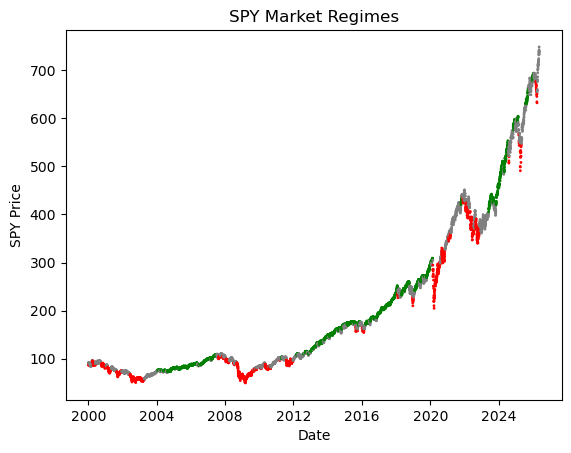

Ticker,SPY,^VIX
Date,,
2000-01-04,-0.039891,27.010000
2000-01-05,0.001787,26.410000
2000-01-06,-0.016202,25.730000
2000-01-07,0.056453,21.719999
2000-01-10,0.003424,21.709999
...,...,...
2026-05-13,0.005579,17.870001
2026-05-14,0.007863,17.260000
2026-05-15,-0.012102,18.430000


In [15]:
spy_aligned = spy_close.loc[df_cleaned.index]
print(spy_aligned.shape)

colors = [{0: "green", 1: "gray", 2: "red"}[s] for s in states]
print(colors[:5])

plt.scatter(df_cleaned.index, spy_aligned, c=colors, s=1)
plt.title("SPY Market Regimes")
plt.xlabel("Date")
plt.ylabel("SPY Price")
plt.show()

df_cleaned

# Feature Engineering

Discretized Log returns: [-∞, -0.0046, 0.0060, ∞]

Decretized VIX: [-∞, 14.01, 23.20, ∞]

Labels: ['low', 'medium', 'high']

dataframe with these five columns — log_return, vix, regime, return_bin, vix_bin.

In [17]:
log_return = df_cleaned['SPY']
vix = df_cleaned['^VIX']
regime = pd.Categorical.from_codes(states, categories=["bull", "sideways", "bear"])
return_bin = pd.cut(df_cleaned['SPY'], bins=[-np.inf, -0.0046, 0.0060, np.inf], labels=["low", "medium", "high"])
vix_bin = pd.cut(df_cleaned['^VIX'], bins=[-np.inf, 14.01, 23.20, np.inf], labels=["low", "neutral", "high"])

df_q_info = pd.DataFrame({
    'log_return': log_return,
    'volatility' : vix,
    'regime': regime,
    'return_disc': return_bin,
    'volatility_disc': vix_bin,
    'spy_close': spy_aligned.squeeze(),
    # market momentum
})

df_q_info

,log_return,volatility,regime,return_disc,volatility_disc,spy_close
Date,,,,,,
2000-01-04,-0.039891,27.010000,bear,low,high,87.794495
2000-01-05,0.001787,26.410000,bear,medium,high,87.951561
2000-01-06,-0.016202,25.730000,bear,low,high,86.538055
2000-01-07,0.056453,21.719999,bear,high,neutral,91.563873
2000-01-10,0.003424,21.709999,sideways,medium,neutral,91.877953
...,...,...,...,...,...,...
2026-05-13,0.005579,17.870001,sideways,medium,neutral,742.309998
2026-05-14,0.007863,17.260000,sideways,high,neutral,748.169983
2026-05-15,-0.012102,18.430000,sideways,low,neutral,739.169983


### Defining Hyperparameters

n_episodes = the number of episodes the loop will run
, alpha = learning rate
, gamma = discount factor (aka how much we value current vs future rewards)
, epsilon = the chance that it explores vs goes with the optimal option according to the q-table
, epsilon_decay = the amount of decay per episode to slowly reduce the amount of exploration
, epsilon_min = the minimum value of epsilon so there's always still a chance to explore

In [19]:
# hyperparameters
n_episodes = 10000
alpha = 0.1
gamma = 0.90
epsilon = 1.0
epsilon_decay = 0.9995
epsilon_min = 0.01
transaction_cost = 0.001 

### Defining our Q-Table

The Q-table will hold 81 values, each state being a combination of the regime, discretized return, and discretized vix. Each cell will hold a dict to tell the agent how often to buy, sell, or hold.

In [21]:
q_table = {}
regimes = ["bull", "sideways", "bear"]
return_bins = ["low", "medium", "high"]
vix_bins = ["low", "neutral", "high"]
actions = ['buy', 'sell', 'hold']

for r in regimes:
    for rb in return_bins:
        for vb in vix_bins:
            state = (r, rb, vb)
            q_table[state] = {'buy': 0.0, 'sell': 0.0, 'hold': 0.0} 

In [22]:
n_passes = 500
episode_rewards = []
episode_trades = []
episode = 0

window_size = 5 * 252 
step_size = 252      
max_start = 5040 - window_size
num_windows = max_start // step_size

print(f"Total windows per pass: {num_windows}")
print(f"Number of passes: {n_passes}")
print(f"Total episodes: {num_windows * n_passes}")
print(f"{'='*60}\n")

for pass_num in range(n_passes):
    print(f"\n{'='*60}")
    print(f"PASS {pass_num + 1}/{n_passes}")
    print(f"{'='*60}")
    
    for window_num in range(num_windows):
        start_idx = window_num * step_size
        end_idx = start_idx + window_size
        
        # get this window's data
        episode_data = df_q_info.iloc[start_idx:end_idx]
        
        if (episode + 1) % 100 == 0 or (pass_num == 0 and window_num < 5):
            print(f"\nEpisode {episode + 1} | Pass {pass_num + 1} | Window {window_num + 1}/{num_windows}")
            start_date = episode_data.index[0].strftime('%Y-%m-%d')
            end_date = episode_data.index[-1].strftime('%Y-%m-%d')
            print(f"Training on: {start_date} to {end_date}")
        
        money = 10000
        num_shares = 0
        total_reward = 0
        num_trades = 0
        
        for i, row in enumerate(episode_data.itertuples(index=False)):
            current_state = (row.regime, row.return_disc, row.volatility_disc)
            current_stock_price = row.spy_close
            before_portfolio_value = (num_shares * current_stock_price) + money
            
            # e-greedy action selection
            if random.random() < epsilon:
                next_action = random.choice(actions)
            else:
                next_action = actions[np.argmax(q_table[current_state])]
            
            position_changed = False
            
            # execute action
            if next_action == 'buy' and money > current_stock_price:
                shares_to_buy = math.floor(money / current_stock_price)
                purchase_cost = current_stock_price * shares_to_buy
                transaction_fee = purchase_cost * transaction_cost
                
                money -= purchase_cost
                money -= transaction_fee
                num_shares += shares_to_buy
                
                if shares_to_buy > 0:
                    position_changed = True
                    num_trades += 1
                    
            elif next_action == 'sell' and num_shares > 0:
                sale_proceeds = num_shares * current_stock_price
                transaction_fee = sale_proceeds * transaction_cost
                
                money += sale_proceeds
                money -= transaction_fee
                num_shares = 0
                position_changed = True
                num_trades += 1
            
            # calculate reward & update q-table
            if i + 1 < len(episode_data):
                next_row = episode_data.iloc[i + 1]
                next_stock_price = next_row.spy_close
                after_portfolio_value = (num_shares * next_stock_price) + money
                
                portfolio_return = (after_portfolio_value - before_portfolio_value) / before_portfolio_value
                reward = portfolio_return
                total_reward += reward
                
                next_state = (next_row.regime, next_row.return_disc, next_row.volatility_disc)
                
                # q-learning update
                current_q = q_table[current_state][next_action]
                max_next_q = max(q_table[next_state].values())
                new_q = current_q + alpha * (reward + gamma * max_next_q - current_q)
                q_table[current_state][next_action] = new_q
        
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        episode_rewards.append(total_reward)
        episode_trades.append(num_trades)
        episode += 1
        
        if (episode) % 100 == 0:
            avg_reward_last_100 = np.mean(episode_rewards[-100:])
            avg_trades_last_100 = np.mean(episode_trades[-100:])
            print(f"  Episode {episode} | Epsilon: {epsilon:.3f} | Avg Reward (last 100): {avg_reward_last_100:.4f} | Avg Trades: {avg_trades_last_100:.0f}")

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Total episodes: {episode}")
print(f"Final epsilon: {epsilon:.3f}")
print(f"Average reward (all episodes): {np.mean(episode_rewards):.4f}")
print(f"Average trades (all episodes): {np.mean(episode_trades):.0f}")

Total windows per pass: 15
Number of passes: 500
Total episodes: 7500


PASS 1/500

Episode 1 | Pass 1 | Window 1/15
Training on: 2000-01-04 to 2005-01-07

Episode 2 | Pass 1 | Window 2/15
Training on: 2001-01-03 to 2006-01-09

Episode 3 | Pass 1 | Window 3/15
Training on: 2002-01-09 to 2007-01-10

Episode 4 | Pass 1 | Window 4/15
Training on: 2003-01-09 to 2008-01-10

Episode 5 | Pass 1 | Window 5/15
Training on: 2004-01-09 to 2009-01-09

PASS 2/500

PASS 3/500

PASS 4/500

PASS 5/500

PASS 6/500

PASS 7/500

Episode 100 | Pass 7 | Window 10/15
Training on: 2009-01-12 to 2014-01-13
  Episode 100 | Epsilon: 0.951 | Avg Reward (last 100): -0.2212 | Avg Trades: 425

PASS 8/500

PASS 9/500

PASS 10/500

PASS 11/500

PASS 12/500

PASS 13/500

PASS 14/500

Episode 200 | Pass 14 | Window 5/15
Training on: 2004-01-09 to 2009-01-09
  Episode 200 | Epsilon: 0.905 | Avg Reward (last 100): -0.2186 | Avg Trades: 430

PASS 15/500

PASS 16/500

PASS 17/500

PASS 18/500

PASS 19/500

PASS 20/500

Epi

In [23]:
final_value = money + (num_shares * df_q_info.iloc[-1].spy_close)
print(f"Started with: $10,000") 
print(f"Ended with: ${final_value:.2f}")
print(f"Return: {((final_value - 10000) / 10000) * 100:.2f}%") 

Started with: $10,000
Ended with: $45684.54
Return: 356.85%


### Compare to a Buy & Hold Baseline

In [25]:
# buy-and-hold 
subset = df_q_info.loc['2020-01-01':'2026-05-19'] 

buy_hold_start_price = subset.iloc[0].spy_close
buy_hold_shares = 10000 / buy_hold_start_price
buy_hold_end_price = subset.iloc[-1].spy_close
buy_hold_final_value = buy_hold_shares * buy_hold_end_price
buy_hold_return = (buy_hold_final_value - 10000) / 10000

print(f"\n=== Buy-and-Hold Baseline ===")
print(f"Started with: $10,000")
print(f"Bought {buy_hold_shares:.2f} shares at ${buy_hold_start_price:.2f}")
print(f"Sold at ${buy_hold_end_price:.2f}")
print(f"Ended with: ${buy_hold_final_value:.2f}")
print(f"Return: {buy_hold_return * 100:.2f}%")
print(f"Trades: 2 (buy at start, sell at end)")

print(f"\n=== Q-Learning Agent ===")
print(f"Started with: $10,000")
print(f"Ended with: ${final_value:.2f}")
print(f"Return: {((final_value - 10000) / 10000) * 100:.2f}%")
print(f"Trades: {num_trades}")

# Also check date range
print(f"\n=== Data Info ===")
print(f"Start date: {subset.index[0] if hasattr(df_q_info, 'index') else 'N/A'}")
print(f"End date: {subset.index[-1] if hasattr(df_q_info, 'index') else 'N/A'}")
print(f"Total days: {len(subset)}")


=== Buy-and-Hold Baseline ===
Started with: $10,000
Bought 33.68 shares at $296.89
Sold at $733.73
Ended with: $24714.02
Return: 147.14%
Trades: 2 (buy at start, sell at end)

=== Q-Learning Agent ===
Started with: $10,000
Ended with: $45684.54
Return: 356.85%
Trades: 17

=== Data Info ===
Start date: 2020-01-02 00:00:00
End date: 2026-05-19 00:00:00
Total days: 1603


In [26]:
print("\n" + "="*60)
print("TESTING LEARNED POLICY ON TEST PERIOD (2020-2026)")
print("="*60 + "\n")

# reset portfolio
test_money = 10000
test_num_shares = 0
test_trades = 0
test_portfolio_history = []

# pure exploitation 
epsilon_test = 0.0

# Run through test dataset with learned q-table
for i, row in enumerate(subset.itertuples(index=False)):
    current_state = (row.regime, row.return_disc, row.volatility_disc)
    current_stock_price = row.spy_close
    
    # learned policy (argmax of q-values)
    q_values = [q_table[current_state][action] for action in actions]
    next_action = actions[np.argmax(q_values)]
    
    if next_action == 'buy' and test_money > current_stock_price:
        shares_to_buy = math.floor(test_money / current_stock_price)
        purchase_cost = current_stock_price * shares_to_buy
        transaction_fee = purchase_cost * transaction_cost
        
        test_money -= purchase_cost
        test_money -= transaction_fee
        test_num_shares += shares_to_buy
        
        if shares_to_buy > 0:
            test_trades += 1
            
    elif next_action == 'sell' and test_num_shares > 0:
        sale_proceeds = test_num_shares * current_stock_price
        transaction_fee = sale_proceeds * transaction_cost
        
        test_money += sale_proceeds
        test_money -= transaction_fee
        test_num_shares = 0
        test_trades += 1
    
    portfolio_value = test_money + (test_num_shares * current_stock_price)
    test_portfolio_history.append(portfolio_value)

test_final_value = test_money + (test_num_shares * subset.iloc[-1].spy_close)
test_return = (test_final_value - 10000) / 10000

print(test_final_value)
print(test_return)
print(q_table)


TESTING LEARNED POLICY ON TEST PERIOD (2020-2026)

24446.04587158203
1.4446045871582032
{('bull', 'low', 'low'): {'buy': 0.012565249976522261, 'sell': 0.0077725816335523215, 'hold': 0.008938356829406906}, ('bull', 'low', 'neutral'): {'buy': 0.014844350138121725, 'sell': 0.009977033187983965, 'hold': 0.015233246434806133}, ('bull', 'low', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0}, ('bull', 'medium', 'low'): {'buy': 0.010808240188979594, 'sell': 0.009158900002643437, 'hold': 0.011994403294998776}, ('bull', 'medium', 'neutral'): {'buy': 0.010429430040849664, 'sell': 0.010188347547767488, 'hold': 0.01410086155460571}, ('bull', 'medium', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0}, ('bull', 'high', 'low'): {'buy': 0.012204492271343136, 'sell': 0.00834298371136244, 'hold': 0.009237268754553754}, ('bull', 'high', 'neutral'): {'buy': 0.012024558445662154, 'sell': 0.010330176051410837, 'hold': 0.012813811087405626}, ('bull', 'high', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0}, ('